In [1]:
import re, time, math, random
from dataclasses import dataclass
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
DATA_PATH = "poems-100.csv"


with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Chars:", len(raw_text))
print(raw_text[:500])

Chars: 139441
text
"O my Luve's like a red, red rose
That’s newly sprung in June;
O my Luve's like the melodie
That’s sweetly play'd in tune.

As fair art thou, my bonnie lass,
So deep in luve am I:
And I will luve thee still, my dear,
Till a’ the seas gang dry:

Till a’ the seas gang dry, my dear,
And the rocks melt wi’ the sun:
I will luve thee still, my dear,
While the sands o’ life shall run.

And fare thee well, my only Luve
And fare thee well, a while!
And I will come again, my Luve,
Tho’ it were ten th


In [3]:
def tokenize_words(text: str):
    text = text.lower()
    text = text.replace("—", " - ").replace("–", " - ")
    tokens = re.findall(r"[a-z']+|\d+|[.,!?;:()\[\]{}\-\"]", text)
    return tokens

tokens = tokenize_words(raw_text)
print("Tokens:", len(tokens))
print(tokens[:50])

SPECIAL = ["<pad>", "<unk>", "<bos>", "<eos>"]

min_freq = 1
cnt = Counter(tokens)
vocab = SPECIAL + [w for w, c in cnt.items() if c >= min_freq and w not in SPECIAL]
vocab = list(dict.fromkeys(vocab))

stoi = {w:i for i,w in enumerate(vocab)}
itos = {i:w for w,i in stoi.items()}

vocab_size = len(vocab)
print("Vocab size:", vocab_size)
print("Most common:", cnt.most_common(10))

Tokens: 29699
['text', '"', 'o', 'my', "luve's", 'like', 'a', 'red', ',', 'red', 'rose', 'that', 's', 'newly', 'sprung', 'in', 'june', ';', 'o', 'my', "luve's", 'like', 'the', 'melodie', 'that', 's', 'sweetly', "play'd", 'in', 'tune', '.', 'as', 'fair', 'art', 'thou', ',', 'my', 'bonnie', 'lass', ',', 'so', 'deep', 'in', 'luve', 'am', 'i', ':', 'and', 'i', 'will']
Vocab size: 5321
Most common: [(',', 2558), ('the', 1806), ('and', 1213), ('of', 757), ('i', 695), ('.', 622), ('-', 537), ('to', 424), ('in', 374), ('a', 373)]


In [4]:
def build_corpus_sequences(text: str):
    lines = [ln.strip() for ln in text.splitlines()]
    lines = [ln for ln in lines if ln]
    seqs = []
    for ln in lines:
        t = tokenize_words(ln)
        if not t:
            continue
        seqs.extend(["<bos>"] + t + ["<eos>"])
    return seqs

corpus = build_corpus_sequences(raw_text)
print("Corpus tokens:", len(corpus))
print(corpus[:60])

def to_ids(tok_list):
    return [stoi.get(t, stoi["<unk>"]) for t in tok_list]

corpus_ids = to_ids(corpus)

@dataclass
class LMConfig:
    seq_len: int = 20
    batch_size: int = 64

cfg = LMConfig(seq_len=20, batch_size=64)

class NextWordDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return max(0, len(self.ids) - self.seq_len - 1)

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx:idx+self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx+1:idx+self.seq_len+1], dtype=torch.long)
        return x, y

ds = NextWordDataset(corpus_ids, cfg.seq_len)
dl = DataLoader(ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)

next(iter(dl))[0].shape, next(iter(dl))[1].shape

Corpus tokens: 35681
['<bos>', 'text', '<eos>', '<bos>', '"', 'o', 'my', "luve's", 'like', 'a', 'red', ',', 'red', 'rose', '<eos>', '<bos>', 'that', 's', 'newly', 'sprung', 'in', 'june', ';', '<eos>', '<bos>', 'o', 'my', "luve's", 'like', 'the', 'melodie', '<eos>', '<bos>', 'that', 's', 'sweetly', "play'd", 'in', 'tune', '.', '<eos>', '<bos>', 'as', 'fair', 'art', 'thou', ',', 'my', 'bonnie', 'lass', ',', '<eos>', '<bos>', 'so', 'deep', 'in', 'luve', 'am', 'i', ':']


(torch.Size([64, 20]), torch.Size([64, 20]))

In [5]:
class OneHotRNNLM(nn.Module):
    def __init__(self, vocab_size, hidden_size=256, num_layers=1, rnn_type="rnn", dropout=0.0):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.rnn_type = rnn_type.lower()

        if self.rnn_type == "lstm":
            self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=hidden_size,
                               num_layers=num_layers, batch_first=True,
                               dropout=dropout if num_layers > 1 else 0.0)
        else:
            self.rnn = nn.RNN(input_size=vocab_size, hidden_size=hidden_size,
                              num_layers=num_layers, batch_first=True,
                              nonlinearity="tanh",
                              dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x_idx, hidden=None):
        x_oh = F.one_hot(x_idx, num_classes=self.vocab_size).float()
        out, hidden = self.rnn(x_oh, hidden)
        logits = self.fc(out)
        return logits, hidden


class EmbeddingRNNLM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_size=256, num_layers=1, rnn_type="rnn", dropout=0.0):
        super().__init__()
        self.rnn_type = rnn_type.lower()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        if self.rnn_type == "lstm":
            self.rnn = nn.LSTM(input_size=embed_dim, hidden_size=hidden_size,
                               num_layers=num_layers, batch_first=True,
                               dropout=dropout if num_layers > 1 else 0.0)
        else:
            self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_size,
                              num_layers=num_layers, batch_first=True,
                              nonlinearity="tanh",
                              dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x_idx, hidden=None):
        x = self.embed(x_idx)
        out, hidden = self.rnn(x, hidden)
        logits = self.fc(out)
        return logits, hidden

In [6]:
def train_language_model(model, dataloader, epochs=5, lr=1e-3, clip=1.0, print_every=100):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    losses = []
    t0 = time.time()

    step = 0
    model.train()
    for ep in range(1, epochs+1):
        running = 0.0
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            opt.zero_grad(set_to_none=True)
            logits, _ = model(x)

            B, T, V = logits.shape
            loss = loss_fn(logits.view(B*T, V), y.view(B*T))
            loss.backward()

            if clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip)

            opt.step()

            running += loss.item()
            step += 1
            if step % print_every == 0:
                avg = running / print_every
                losses.append(avg)
                running = 0.0
                print(f"epoch {ep}/{epochs} step {step}  loss={avg:.4f}")

    t1 = time.time()
    return {"losses": losses, "train_time_sec": t1 - t0, "model": model}

@torch.no_grad()
def sample_next_token(logits, temperature=1.0, top_k=None):
    logits = logits / max(temperature, 1e-8)
    probs = F.softmax(logits, dim=-1)

    if top_k is not None and top_k > 0:
        topv, topi = torch.topk(probs, k=min(top_k, probs.numel()))
        topv = topv / topv.sum()
        choice = topi[torch.multinomial(topv, 1)]
        return int(choice.item())
    else:
        return int(torch.multinomial(probs, 1).item())

@torch.no_grad()
def generate_text(model, prompt, max_new_tokens=60, temperature=1.0, top_k=40):
    model.eval()
    toks = tokenize_words(prompt)
    if not toks:
        toks = ["<bos>"]
    toks = ["<bos>"] + toks
    ids = [stoi.get(t, stoi["<unk>"]) for t in toks]
    hidden = None

    x = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)
    logits, hidden = model(x, hidden)
    last_id = ids[-1]

    out_ids = ids.copy()

    for _ in range(max_new_tokens):
        x = torch.tensor([[last_id]], dtype=torch.long, device=device)
        logits, hidden = model(x, hidden)
        next_logits = logits[0, -1]
        next_id = sample_next_token(next_logits, temperature=temperature, top_k=top_k)

        out_ids.append(next_id)
        last_id = next_id

        if itos[next_id] == "<eos>":
            break

    words = [itos[i] for i in out_ids if itos[i] not in ("<bos>", "<pad>")]
    s = ""
    for w in words:
        if w in [".", ",", "!", "?", ";", ":", ")", "]", "}", """]:
            s = s.rstrip() + w + " "
        elif w in ["(", "[", "{", """]:
            s += w
        elif w == "<eos>":
            s += "\n"
        else:
            s += w + " "
    return s.strip()

In [7]:
EPOCHS = 8
LR = 2e-3
HIDDEN = 256
LAYERS = 1
DROPOUT = 0.0

onehot_rnn = OneHotRNNLM(vocab_size, hidden_size=HIDDEN, num_layers=LAYERS, rnn_type="rnn", dropout=DROPOUT)
onehot_lstm = OneHotRNNLM(vocab_size, hidden_size=HIDDEN, num_layers=LAYERS, rnn_type="lstm", dropout=DROPOUT)

print("Training One-Hot RNN...")
res_onehot_rnn = train_language_model(onehot_rnn, dl, epochs=EPOCHS, lr=LR, print_every=100)

print("\nTraining One-Hot LSTM...")
res_onehot_lstm = train_language_model(onehot_lstm, dl, epochs=EPOCHS, lr=LR, print_every=100)

res_onehot_rnn["train_time_sec"], res_onehot_lstm["train_time_sec"]

Training One-Hot RNN...


epoch 1/8 step 100  loss=6.2118


epoch 1/8 step 200  loss=5.7652


epoch 1/8 step 300  loss=5.2817


epoch 1/8 step 400  loss=4.8935


...

epoch 8/8 step 4100  loss=0.4192


epoch 8/8 step 4200  loss=0.4128


epoch 8/8 step 4300  loss=0.4061


epoch 8/8 step 4400  loss=0.4086


(38.819212675094604, 72.67219114303589)

In [8]:
EMBED_DIM = 128

emb_rnn = EmbeddingRNNLM(vocab_size, embed_dim=EMBED_DIM, hidden_size=HIDDEN, num_layers=LAYERS, rnn_type="rnn", dropout=DROPOUT)
emb_lstm = EmbeddingRNNLM(vocab_size, embed_dim=EMBED_DIM, hidden_size=HIDDEN, num_layers=LAYERS, rnn_type="lstm", dropout=DROPOUT)

print("Training Embedding RNN...")
res_emb_rnn = train_language_model(emb_rnn, dl, epochs=EPOCHS, lr=LR, print_every=100)

print("\nTraining Embedding LSTM...")
res_emb_lstm = train_language_model(emb_lstm, dl, epochs=EPOCHS, lr=LR, print_every=100)

res_emb_rnn["train_time_sec"], res_emb_lstm["train_time_sec"]

Training Embedding RNN...


epoch 1/8 step 100  loss=5.3485


epoch 1/8 step 200  loss=4.2096


epoch 1/8 step 300  loss=3.4734


epoch 1/8 step 400  loss=2.8613


...

epoch 8/8 step 4100  loss=0.3483


epoch 8/8 step 4200  loss=0.3521


epoch 8/8 step 4300  loss=0.3571


epoch 8/8 step 4400  loss=0.3563


(27.150903940200806, 29.03984832763672)

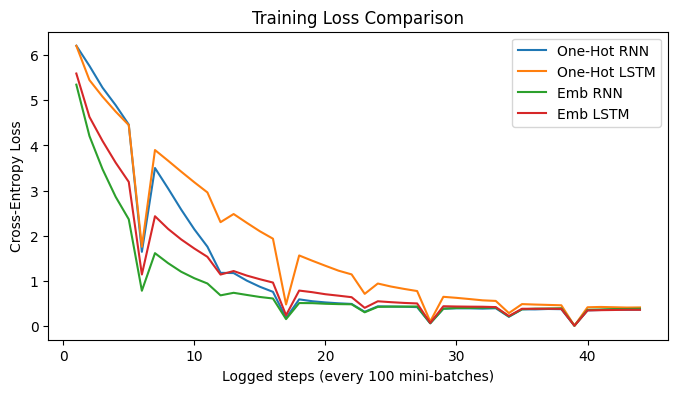

{'One-Hot RNN': 38.819212675094604,
 'One-Hot LSTM': 72.67219114303589,
 'Emb RNN': 27.150903940200806,
 'Emb LSTM': 29.03984832763672}

In [9]:
import matplotlib.pyplot as plt

def plot_losses(label_to_losses):
    plt.figure(figsize=(8,4))
    for label, losses in label_to_losses.items():
        if len(losses) == 0:
            continue
        plt.plot(range(1, len(losses)+1), losses, label=label)
    plt.xlabel("Logged steps (every 100 mini-batches)")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.title("Training Loss Comparison")
    plt.show()

plot_losses({
    "One-Hot RNN": res_onehot_rnn["losses"],
    "One-Hot LSTM": res_onehot_lstm["losses"],
    "Emb RNN": res_emb_rnn["losses"],
    "Emb LSTM": res_emb_lstm["losses"],
})

times = {
    "One-Hot RNN": res_onehot_rnn["train_time_sec"],
    "One-Hot LSTM": res_onehot_lstm["train_time_sec"],
    "Emb RNN": res_emb_rnn["train_time_sec"],
    "Emb LSTM": res_emb_lstm["train_time_sec"],
}
times

In [10]:
PROMPT = "in the silent night"
TEMP = 0.9
TOPK = 40
NEW_TOKENS = 80

print("=== One-Hot RNN ===")
print(generate_text(res_onehot_rnn["model"], PROMPT, max_new_tokens=NEW_TOKENS, temperature=TEMP, top_k=TOPK))
print("\n=== One-Hot LSTM ===")
print(generate_text(res_onehot_lstm["model"], PROMPT, max_new_tokens=NEW_TOKENS, temperature=TEMP, top_k=TOPK))

print("\n=== Embedding RNN ===")
print(generate_text(res_emb_rnn["model"], PROMPT, max_new_tokens=NEW_TOKENS, temperature=TEMP, top_k=TOPK))
print("\n=== Embedding LSTM ===")
print(generate_text(res_emb_lstm["model"], PROMPT, max_new_tokens=NEW_TOKENS, temperature=TEMP, top_k=TOPK))

=== One-Hot RNN ===
in the silent night

=== One-Hot LSTM ===
in the silent night - whom we know know

=== Embedding RNN ===
in the silent night ,

=== Embedding LSTM ===
in the silent night of south ,and sound ,
